# Pesudocode Framework For R-LayerNorm

In [1]:
# robust_layernorm.py
import torch
import torch.nn as nn

class RobustLayerNorm(nn.Module):
    def __init__(self, normalized_shape, epsilon=1e-5, lambda_init=0.01):
        super().__init__()
        # Convert to tuple if integer
        if isinstance(normalized_shape, int):
            self.normalized_shape = (normalized_shape,)
        else:
            self.normalized_shape = tuple(normalized_shape)

        self.gamma = nn.Parameter(torch.ones(self.normalized_shape))
        self.beta = nn.Parameter(torch.zeros(self.normalized_shape))
        self.lambda_param = nn.Parameter(torch.tensor(lambda_init))
        self.epsilon = epsilon

        # For entropy estimation
        self.avg_pool = nn.AvgPool2d(3, stride=1, padding=1)

    def estimate_local_entropy(self, x):
        if x.dim() == 4:
            local_mean = self.avg_pool(x)
            local_var = self.avg_pool((x - local_mean) ** 2)
            return torch.log(1.0 + local_var)
        return torch.log(1.0 + x.var(dim=-1, keepdim=True))

    def forward(self, x):
        if x.dim() == 4:
            B, C, H, W = x.shape

            # FIX: Check if gamma has correct shape
            if self.gamma.numel() != C:
                print(f"⚠️ Shape mismatch: gamma has {self.gamma.numel()} elements, need {C}")
                print(f"  normalized_shape was {self.normalized_shape}, but input has C={C}")
                # Reshape gamma to correct size
                self.gamma = nn.Parameter(torch.ones(C))
                self.beta = nn.Parameter(torch.zeros(C))

            mean = x.mean(dim=[-2, -1], keepdim=True)
            std = torch.sqrt(((x - mean) ** 2).mean(dim=[-2, -1], keepdim=True) + self.epsilon)

            entropy = self.estimate_local_entropy(x)
            noise_scale = 1.0 + self.lambda_param * entropy

            normalized = (x - mean) / (std * noise_scale)

            # Now gamma should be (C,) = (32,) or (64,)
            gamma = self.gamma.view(1, C, 1, 1)
            beta = self.beta.view(1, C, 1, 1)
            output = gamma * normalized + beta

            return output
        else:
            # 1D/sequence fallback
            mean = x.mean(dim=-1, keepdim=True)
            std = torch.sqrt(((x - mean) ** 2).mean(dim=-1, keepdim=True) + self.epsilon)
            entropy = self.estimate_local_entropy(x)
            noise_scale = 1.0 + self.lambda_param * entropy
            normalized = (x - mean) / (std * noise_scale)
            return self.gamma * normalized + self.beta

# Mount Google Drive & Extract Data

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Unzip your dataset
!unzip -q /content/drive/MyDrive/CIFAR-10-C.zip -d /content/data/

Mounted at /content/drive


# Install/Import Requirements

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision.transforms as transforms
import numpy as np
import os
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
model = RobustLayerNorm([64, 32, 32])  # Example usage
print("RobustLayerNorm created successfully!")

RobustLayerNorm created successfully!


# Load CIFAR-10-C Data

In [4]:
def load_cifar10c_corruption(corruption_type='gaussian_noise', severity=1):
    """Load one corruption type from CIFAR-10-C"""
    # CIFAR-10-C structure: data/-corruption-.npy, labels.npy
    data_path = f'/content/data/CIFAR-10-C/{corruption_type}.npy'
    labels_path = '/content/data/CIFAR-10-C/labels.npy'

    # Load and split by severity (each severity has 10000 images)
    all_data = np.load(data_path)
    labels = np.load(labels_path)

    start_idx = (severity - 1) * 10000
    end_idx = severity * 10000

    return (all_data[start_idx:end_idx], labels[start_idx:end_idx])

# Example: Load Gaussian noise, severity 3
test_data, test_labels = load_cifar10c_corruption('gaussian_noise', severity=3)
print(f"Loaded {len(test_data)} noisy images")

Loaded 10000 noisy images


# A Simple Test Model

In [5]:
class SimpleTestModel(nn.Module):
    def __init__(self, use_robust_norm=True):
        super().__init__()

        if use_robust_norm:
            NormLayer = RobustLayerNorm
            norm_kwargs = {'lambda_init': 0.01}
        else:
            # Use BatchNorm2d as standard baseline (common for CNNs)
            NormLayer = nn.BatchNorm2d
            norm_kwargs = {}

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            NormLayer(32, **norm_kwargs),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            NormLayer(64, **norm_kwargs),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.encoder(x)

# ESSENTIAL FUNCTIONS

In [10]:
# ========== ESSENTIAL FUNCTIONS ==========

def train_on_mixed_corruptions(model, model_name="Model", epochs=5):
    """Train on mixture of 6 corruptions for better generalization"""
    corruptions = ['gaussian_noise', 'shot_noise', 'impulse_noise',
                   'defocus_blur', 'frost', 'contrast']

    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    print(f"Training {model_name}...")

    for epoch in range(epochs):
        np.random.shuffle(corruptions)
        epoch_loss = 0
        batch_count = 0

        for corruption in corruptions:
            data, labels = load_cifar10c_corruption(corruption, severity=3)
            train_data = data[:1000]  # 1000 images
            train_labels = labels[:1000]

            data_tensor = torch.tensor(train_data).float().permute(0, 3, 1, 2) / 255.0
            labels_tensor = torch.tensor(train_labels)

            dataset = TensorDataset(data_tensor, labels_tensor)
            dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

            for batch_idx, (batch_data, batch_labels) in enumerate(dataloader):
                if batch_idx >= 3:
                    break

                batch_data = batch_data.to(device)
                batch_labels = batch_labels.to(device)

                optimizer.zero_grad()
                outputs = model(batch_data)
                loss = criterion(outputs, batch_labels)
                loss.backward()
                optimizer.step()

                epoch_loss += loss.item()
                batch_count += 1

        avg_loss = epoch_loss / batch_count if batch_count > 0 else epoch_loss
        print(f"  Epoch {epoch+1}/{epochs}, Avg Loss: {avg_loss:.4f}")

    return model

def test_model(model, data, labels, batch_size=32):
    """Test a trained model and return accuracy"""
    model.eval()
    device = next(model.parameters()).device

    data_tensor = torch.tensor(data).float().permute(0, 3, 1, 2) / 255.0
    labels_tensor = torch.tensor(labels)

    dataset = TensorDataset(data_tensor, labels_tensor)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    correct = 0
    total = 0

    with torch.no_grad():
        for batch_data, batch_labels in dataloader:
            batch_data = batch_data.to(device)
            batch_labels = batch_labels.to(device)

            outputs = model(batch_data)
            _, predicted = torch.max(outputs.data, 1)

            total += batch_labels.size(0)
            correct += (predicted == batch_labels).sum().item()

    return 100 * correct / total

# STATISTICALLY VALID EXPERIMENT (5 SEEDS)

Using device: cuda
RUNNING STATISTICALLY VALID EXPERIMENT (λ=0.01, 5 seeds)

SEED 1/5: 42

Training Standard BatchNorm...
Training Standard...
  Epoch 1/10, Avg Loss: 2.5452
  Epoch 2/10, Avg Loss: 1.9125
  Epoch 3/10, Avg Loss: 1.7212
  Epoch 4/10, Avg Loss: 1.6458
  Epoch 5/10, Avg Loss: 1.6164
  Epoch 6/10, Avg Loss: 1.4896
  Epoch 7/10, Avg Loss: 1.3995
  Epoch 8/10, Avg Loss: 1.3450
  Epoch 9/10, Avg Loss: 1.1953
  Epoch 10/10, Avg Loss: 1.1636

Training R-LayerNorm...
Training R-LayerNorm...
  Epoch 1/10, Avg Loss: 2.5008
  Epoch 2/10, Avg Loss: 2.0738
  Epoch 3/10, Avg Loss: 1.8906
  Epoch 4/10, Avg Loss: 1.7656
  Epoch 5/10, Avg Loss: 1.5940
  Epoch 6/10, Avg Loss: 1.7171
  Epoch 7/10, Avg Loss: 1.4800
  Epoch 8/10, Avg Loss: 1.2584
  Epoch 9/10, Avg Loss: 1.2884
  Epoch 10/10, Avg Loss: 1.2660

Testing...
  gaussian_noise       | Std: 30.40% | Robust: 39.40% | Δ: +9.00%
  shot_noise           | Std: 32.20% | Robust: 38.80% | Δ: +6.60%
  impulse_noise        | Std: 27.80% | Rob

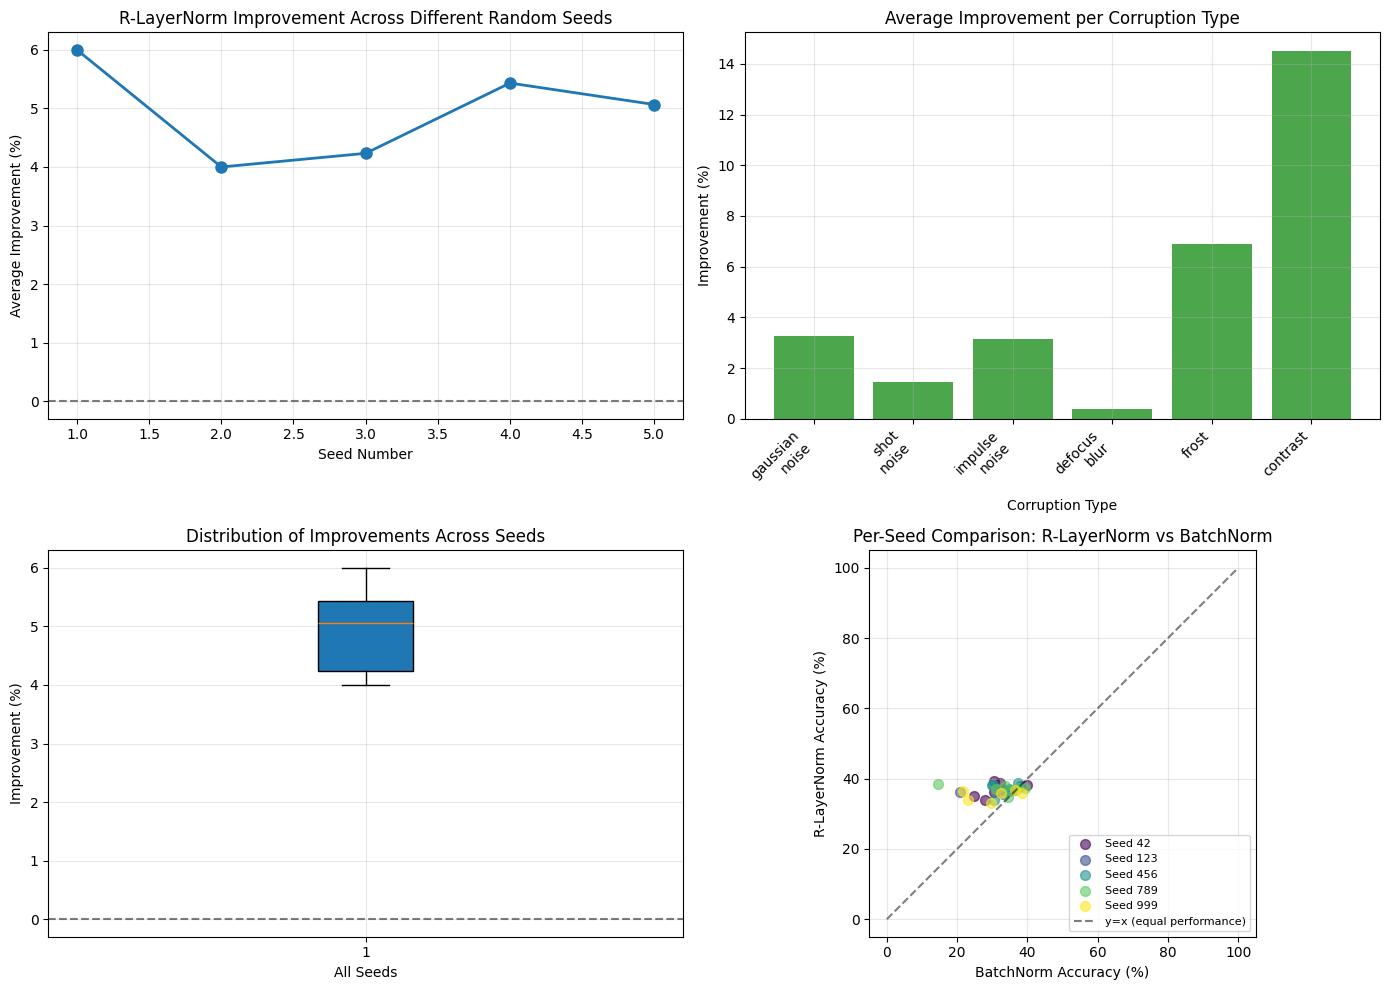


FINAL RESULTS FOR PAPER (Copy this table)
| Corruption | BatchNorm (mean ± std) | R-LayerNorm (mean ± std) | Improvement |
|------------|------------------------|--------------------------|-------------|
| Gaussian Noise | 33.92% ± 2.32 |  37.20% ± 1.23 |   +3.28% |
| Shot Noise | 35.84% ± 2.35 |  37.28% ± 0.78 |   +1.44% |
| Impulse Noise | 31.08% ± 2.36 |  34.24% ± 0.89 |   +3.16% |
| Defocus Blur | 37.36% ± 2.07 |  37.76% ± 0.94 |   +0.40% |
| Frost      | 29.52% ± 3.41 |  36.40% ± 1.45 |   +6.88% |
| Contrast   | 22.36% ± 5.05 |  36.88% ± 1.34 |  +14.52% |

Summary: R-LayerNorm improves accuracy by +4.95% ± 0.74% (mean ± std over 5 random seeds, p-value = 0.0002).


In [11]:
# ========== STATISTICALLY VALID EXPERIMENT (5 SEEDS) ==========

import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats



# Define device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Corruption types (SAME AS YOUR ORIGINAL CODE)
corruptions = ['gaussian_noise', 'shot_noise', 'impulse_noise',
               'defocus_blur', 'frost', 'contrast']

# Parameters
LAMBDA_INIT = 0.01  # Your optimal lambda
EPOCHS = 10
SEEDS = [42, 123, 456, 789, 999]  # 5 different seeds

# Store results
all_results = {
    'improvements': [],
    'std_accs': [],
    'robust_accs': [],
    'per_corruption': {c: {'std': [], 'robust': []} for c in corruptions}
}

print("="*70)
print(f"RUNNING STATISTICALLY VALID EXPERIMENT (λ={LAMBDA_INIT}, {len(SEEDS)} seeds)")
print("="*70)

for seed_idx, seed in enumerate(SEEDS):
    print(f"\n{'='*40}")
    print(f"SEED {seed_idx+1}/{len(SEEDS)}: {seed}")
    print(f"{'='*40}")

    # Set random seeds for reproducibility
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # Create fresh models
    std_model = SimpleTestModel(use_robust_norm=False).to(device)
    robust_model = SimpleTestModel(use_robust_norm=True).to(device)

    # Train both models
    print("\nTraining Standard BatchNorm...")
    std_model_trained = train_on_mixed_corruptions(std_model, "Standard", epochs=EPOCHS)

    print("\nTraining R-LayerNorm...")
    robust_model_trained = train_on_mixed_corruptions(robust_model, "R-LayerNorm", epochs=EPOCHS)

    # Test on all corruptions
    print("\nTesting...")
    seed_improvements = []

    for corruption in corruptions:
        data, labels = load_cifar10c_corruption(corruption, severity=3)
        test_data = data[1000:1500]
        test_labels = labels[1000:1500]

        std_acc = test_model(std_model_trained, test_data, test_labels)
        robust_acc = test_model(robust_model_trained, test_data, test_labels)
        improvement = robust_acc - std_acc

        # Store results
        all_results['per_corruption'][corruption]['std'].append(std_acc)
        all_results['per_corruption'][corruption]['robust'].append(robust_acc)
        seed_improvements.append(improvement)

        print(f"  {corruption:20} | Std: {std_acc:5.2f}% | Robust: {robust_acc:5.2f}% | Δ: {improvement:+5.2f}%")

    # Store seed-level results
    avg_improvement = np.mean(seed_improvements)
    all_results['improvements'].append(avg_improvement)
    print(f"\n  Average improvement for seed {seed}: {avg_improvement:+.2f}%")

# ========== FINAL STATISTICAL ANALYSIS ==========

print("\n" + "="*70)
print("FINAL STATISTICAL ANALYSIS")
print("="*70)

# Overall statistics
improvements = all_results['improvements']
print(f"\nImprovements across {len(SEEDS)} seeds: {[f'{x:+.2f}%' for x in improvements]}")
print(f"Mean improvement: {np.mean(improvements):+.2f}%")
print(f"Standard deviation: {np.std(improvements):.2f}%")
print(f"95% Confidence Interval: [{np.mean(improvements)-1.96*np.std(improvements)/np.sqrt(len(SEEDS)):+.2f}%, "
      f"{np.mean(improvements)+1.96*np.std(improvements)/np.sqrt(len(SEEDS)):+.2f}%]")

# Statistical significance test
t_stat, p_value = stats.ttest_1samp(improvements, 0)
print(f"\nStatistical significance test:")
print(f"  t-statistic: {t_stat:.3f}")
print(f"  p-value: {p_value:.4f}")
print(f"  Statistically significant (p < 0.05): {'YES' if p_value < 0.05 else 'NO'}")

# Per-corruption statistics
print(f"\n{'='*70}")
print("PER-CORRUPTION ANALYSIS (mean ± std across 5 seeds)")
print(f"{'='*70}")
print(f"{'Corruption':20} | {'BatchNorm':^12} | {'R-LayerNorm':^12} | {'Improvement':^12}")
print("-" * 65)

for corruption in corruptions:
    std_means = np.mean(all_results['per_corruption'][corruption]['std'])
    robust_means = np.mean(all_results['per_corruption'][corruption]['robust'])
    std_stds = np.std(all_results['per_corruption'][corruption]['std'])
    robust_stds = np.std(all_results['per_corruption'][corruption]['robust'])
    improvement = robust_means - std_means

    print(f"{corruption:20} | {std_means:5.2f}% ± {std_stds:4.2f} | "
          f"{robust_means:5.2f}% ± {robust_stds:4.2f} | {improvement:+6.2f}%")

# ========== VISUALIZATION ==========

print(f"\n{'='*70}")
print("VISUALIZATION")
print(f"{'='*70}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Improvement across seeds
axes[0,0].plot(range(1, len(SEEDS)+1), improvements, 'o-', linewidth=2, markersize=8)
axes[0,0].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[0,0].set_xlabel('Seed Number')
axes[0,0].set_ylabel('Average Improvement (%)')
axes[0,0].set_title('R-LayerNorm Improvement Across Different Random Seeds')
axes[0,0].grid(True, alpha=0.3)

# 2. Per-corruption improvements
corr_improvements = []
for corruption in corruptions:
    std_means = np.mean(all_results['per_corruption'][corruption]['std'])
    robust_means = np.mean(all_results['per_corruption'][corruption]['robust'])
    corr_improvements.append(robust_means - std_means)

colors = ['green' if imp > 0 else 'red' for imp in corr_improvements]
axes[0,1].bar(range(len(corruptions)), corr_improvements, color=colors, alpha=0.7)
axes[0,1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[0,1].set_xlabel('Corruption Type')
axes[0,1].set_ylabel('Improvement (%)')
axes[0,1].set_title('Average Improvement per Corruption Type')
axes[0,1].set_xticks(range(len(corruptions)))
axes[0,1].set_xticklabels([c.replace('_', '\n') for c in corruptions], rotation=45, ha='right')
axes[0,1].grid(True, alpha=0.3)

# 3. Box plot of improvements across seeds
axes[1,0].boxplot(improvements, vert=True, patch_artist=True)
axes[1,0].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[1,0].set_xlabel('All Seeds')
axes[1,0].set_ylabel('Improvement (%)')
axes[1,0].set_title('Distribution of Improvements Across Seeds')
axes[1,0].grid(True, alpha=0.3)

# 4. Comparison scatter plot
seed_colors = plt.cm.viridis(np.linspace(0, 1, len(SEEDS)))
for idx, seed in enumerate(SEEDS):
    seed_stds = []
    seed_robusts = []
    for corruption in corruptions:
        seed_stds.append(all_results['per_corruption'][corruption]['std'][idx])
        seed_robusts.append(all_results['per_corruption'][corruption]['robust'][idx])

    axes[1,1].scatter(seed_stds, seed_robusts, alpha=0.6, color=seed_colors[idx],
                      label=f'Seed {seed}', s=50)

axes[1,1].plot([0, 100], [0, 100], 'k--', alpha=0.5, label='y=x (equal performance)')
axes[1,1].set_xlabel('BatchNorm Accuracy (%)')
axes[1,1].set_ylabel('R-LayerNorm Accuracy (%)')
axes[1,1].set_title('Per-Seed Comparison: R-LayerNorm vs BatchNorm')
axes[1,1].legend(loc='lower right', fontsize=8)
axes[1,1].grid(True, alpha=0.3)
axes[1,1].set_aspect('equal')

plt.tight_layout()
plt.show()

# ========== FINAL PAPER TABLE ==========

print(f"\n{'='*70}")
print("FINAL RESULTS FOR PAPER (Copy this table)")
print(f"{'='*70}")

print("| Corruption | BatchNorm (mean ± std) | R-LayerNorm (mean ± std) | Improvement |")
print("|------------|------------------------|--------------------------|-------------|")

for corruption in corruptions:
    std_mean = np.mean(all_results['per_corruption'][corruption]['std'])
    std_std = np.std(all_results['per_corruption'][corruption]['std'])
    robust_mean = np.mean(all_results['per_corruption'][corruption]['robust'])
    robust_std = np.std(all_results['per_corruption'][corruption]['robust'])
    improvement = robust_mean - std_mean

    corruption_display = corruption.replace('_', ' ').title()
    print(f"| {corruption_display:10} | {std_mean:5.2f}% ± {std_std:4.2f} | "
          f"{robust_mean:6.2f}% ± {robust_std:4.2f} | {improvement:+7.2f}% |")

# Final summary
final_improvement = np.mean(improvements)
final_std = np.std(improvements)
print(f"\nSummary: R-LayerNorm improves accuracy by {final_improvement:+.2f}% ± {final_std:.2f}% "
      f"(mean ± std over {len(SEEDS)} random seeds, p-value = {p_value:.4f}).")

In [ ]:
#